In [16]:

import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec
from utils import prepareTrainingSet30Sec
from utils import standardization
from utils import metrics, evaluate_Model

from utils import Grafico_Before_After

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score






In [17]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test= standardization(X_train, X_test)

# Creare il modello SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

# Calcolo e stampa delle metriche
#metrics(y_test, y_pred)

before_30sec=accuracy_score(y_test, y_pred)


y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)


---------STATISTICHE TEST----------
Accuratezza: 0.7718
Precision: 0.7706
Recall: 0.7727
F1-score: 0.7701
F2-score: 0.7713
---------STATISTICHE TRAING----------
Accuratezza: 0.8059
Precision: 0.8049
Recall: 0.8058
F1-score: 0.8042
F2-score: 0.8049

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


In [18]:
# Permette di testare diverse configurazioni iperparametriche 
param_grid = {
    'C': [1, 10],
    'gamma': ['scale'] + [0.1,1],
    'kernel': ['rbf','poly']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("I Migliori parametri trovati sono:", grid_search.best_params_)
best_model = grid_search.best_estimator_

KeyboardInterrupt: 

In [24]:

# Creare il modello SVM e applico la funzione kernel consiglata dalla Grid
model = SVC(C=4, gamma='scale', kernel='rbf')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

# Calcolo e stampa delle metriche
after_30sec=accuracy_score(y_test, y_pred)
svm30Sec=after_30sec
y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.9204
Precision: 0.9199
Recall: 0.9195
F1-score: 0.9193
F2-score: 0.9193
---------STATISTICHE TRAING----------
Accuratezza: 0.9842
Precision: 0.9843
Recall: 0.9843
F1-score: 0.9843
F2-score: 0.9842

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


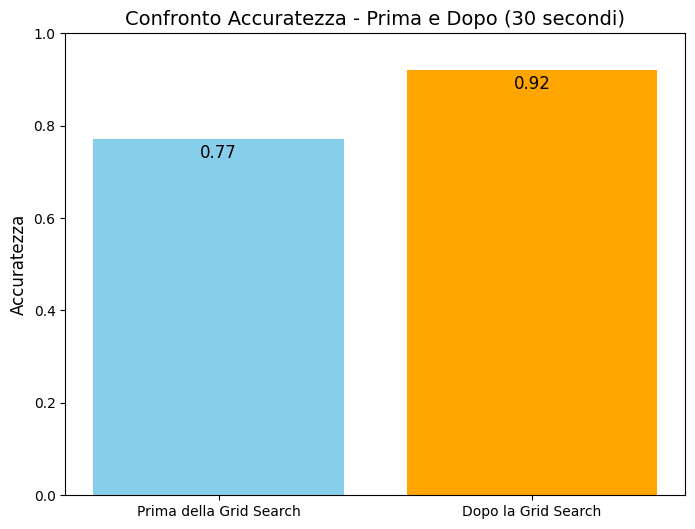

In [25]:
Grafico_Before_After(before_30sec,after_30sec)